In [28]:
import sys
from pathlib import Path
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import json

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

from src.constants import (
    TARGET_COL,
    MULTILABEL_COLS,
    CATEGORICAL_COLS,
    CLASS_LABELS,
    RANDOM_STATE,
    PROCESSED_DATA_PATH,
)
from src.preprocessing import load_processed_dataset
from src.encoders import fit_mlb_encoder, fit_ohe_encoder, build_mlb_ohe_matrix, ARTIFACTS_PATH, save_encoders
from src.visualisations import plot_cluster_distribution

In [29]:
df = load_processed_dataset(PROCESSED_DATA_PATH)

# Fit encoders on the full data (no held-out set in unsupervised analysis)
mlb_encoder = fit_mlb_encoder(df, MULTILABEL_COLS)
ohe_encoder = fit_ohe_encoder(df, CATEGORICAL_COLS)

# Build the MLB + OHE feature matrix for KMeans (fully numeric)
X_cluster = build_mlb_ohe_matrix(df, mlb_encoder, ohe_encoder)

# True labels for post-hoc evaluation against decision_taken
y_true = df[TARGET_COL].reset_index(drop=True)

# Keep raw categorical columns alongside for cluster characterisation later
df_raw = df[MULTILABEL_COLS + CATEGORICAL_COLS + [TARGET_COL]].reset_index(drop=True)

print(f"KMeans input matrix shape: {X_cluster.shape}")
for col, encoder in mlb_encoder.items():
    print(f"\t{col}: {len(encoder.classes_)} unique labels")
assert X_cluster.isnull().sum().sum() == 0
print("\nNo nulls in cluster matrix")

KMeans input matrix shape: (9250, 76)
	data_subject_type: 16 unique labels
	data_type: 26 unique labels

No nulls in cluster matrix


In [30]:
kmeans_inertias    = []
kmeans_silhouettes = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X_cluster)
    kmeans_inertias.append(kmeans.inertia_)
    silhouette = silhouette_score(X_cluster, labels, metric="euclidean")
    kmeans_silhouettes.append(silhouette)
    print(f"K={k:2d}: Inertia={kmeans.inertia_:.1f}, Silhouette={silhouette:.4f}")

K= 2: Inertia=34101.1, Silhouette=0.1350
K= 3: Inertia=31648.5, Silhouette=0.1177
K= 4: Inertia=29946.6, Silhouette=0.1181
K= 5: Inertia=28819.6, Silhouette=0.0924
K= 6: Inertia=27506.9, Silhouette=0.1367
K= 7: Inertia=26662.2, Silhouette=0.1105
K= 8: Inertia=25247.0, Silhouette=0.1503
K= 9: Inertia=24562.4, Silhouette=0.1448
K=10: Inertia=24346.8, Silhouette=0.1326


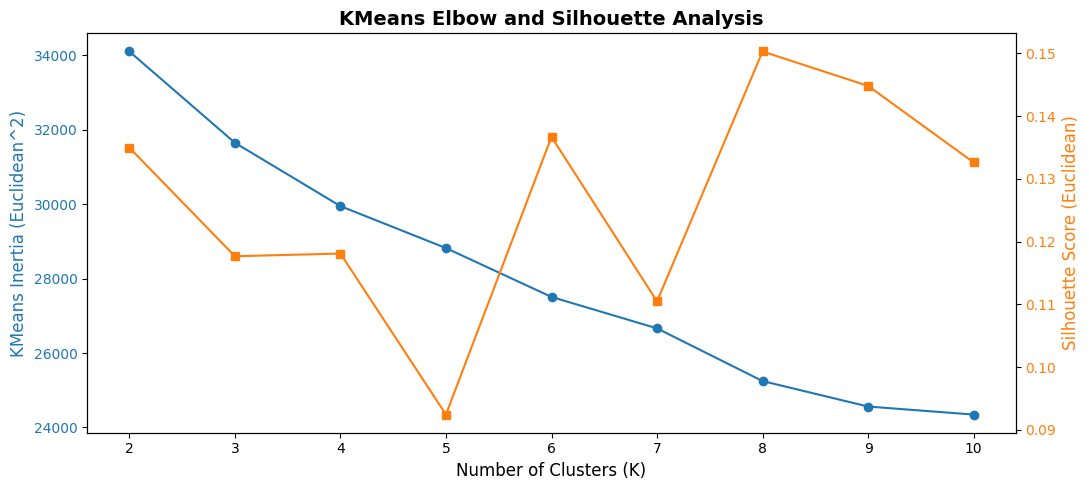

K with highest silhouette: K=8 (score=0.1503)


In [31]:
fig, ax_inertia = plt.subplots(figsize=(11, 5))

colour_inertia = "tab:blue"
ax_inertia.set_xlabel("Number of Clusters (K)", fontsize=12)
ax_inertia.set_ylabel("KMeans Inertia (Euclidean^2)", color=colour_inertia, fontsize=12)
ax_inertia.plot(list(k_range), kmeans_inertias, marker="o", color=colour_inertia)
ax_inertia.tick_params(axis="y", labelcolor=colour_inertia)

ax_silhouette = ax_inertia.twinx()
colour_silhouette = "tab:orange"
ax_silhouette.set_ylabel("Silhouette Score (Euclidean)", color=colour_silhouette, fontsize=12)
ax_silhouette.plot(list(k_range), kmeans_silhouettes, marker="s", color=colour_silhouette)
ax_silhouette.tick_params(axis="y", labelcolor=colour_silhouette)

plt.title("KMeans Elbow and Silhouette Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

best_silhouette_k = list(k_range)[int(np.argmax(kmeans_silhouettes))]
print(f"K with highest silhouette: K={best_silhouette_k} (score={max(kmeans_silhouettes):.4f})")

In [ ]:
final_k = best_silhouette_k

print(f"Fitting final KMeans with K={final_k}")
kmeans_final = KMeans(
    n_clusters=final_k,
    init="k-means++",
    n_init=20,
    random_state=RANDOM_STATE,
)
kmeans_labels = kmeans_final.fit_predict(X_cluster)

print(f"\nCluster sizes:")
sizes = pd.Series(kmeans_labels).value_counts().sort_index()
for cluster_id, count in sizes.items():
    print(f"\tCluster {cluster_id}: {count} breaches ({count/len(kmeans_labels)*100:.1f}%)")

print(f"\nFinal inertia: {kmeans_final.inertia_:.1f}")

Fitting final KMeans with K=8

Cluster sizes:
	Cluster 0: 537 breaches (5.8%)
	Cluster 1: 1479 breaches (16.0%)
	Cluster 2: 737 breaches (8.0%)
	Cluster 3: 1141 breaches (12.3%)
	Cluster 4: 2054 breaches (22.2%)
	Cluster 5: 972 breaches (10.5%)
	Cluster 6: 913 breaches (9.9%)
	Cluster 7: 1417 breaches (15.3%)

Final inertia: 25247.0


In [33]:
df_analysis = df_raw.copy()
df_analysis["cluster"] = kmeans_labels

print("Per-cluster feature dominance:")
for cluster_id in range(final_k):
    cluster_rows = df_analysis[df_analysis["cluster"] == cluster_id]
    print(f"\nCluster {cluster_id} ({len(cluster_rows)} breaches, {len(cluster_rows)/len(df_analysis)*100:.1f}%)")
    for col in MULTILABEL_COLS + CATEGORICAL_COLS:
        top = cluster_rows[col].value_counts(normalize=True).head(1)
        if len(top) > 0:
            value, prop = top.index[0], top.iloc[0]
            print(f"\t{col:30s}: {value} ({prop*100:.1f}%)")

    decision_dist = cluster_rows[TARGET_COL].value_counts(normalize=True)
    print(f"\ndecision outcomes within cluster")
    for label in CLASS_LABELS:
        prop = decision_dist.get(label, 0.0)
        print(f"\t{label:30s}: {prop*100:.1f}%")

Per-cluster feature dominance:

Cluster 0 (537 breaches, 5.8%)
	data_subject_type             : Unknown (95.2%)
	data_type                     : Unknown (97.6%)
	incident_category             : Non Cyber (68.2%)
	incident_type                 : Other non-cyber incident (19.4%)
	no_data_subjects_affected     : Unknown (92.2%)
	time_taken_to_report          : Less than 24 hours (75.2%)

decision outcomes within cluster
	Informal Action Taken         : 65.2%
	Investigation Pursued         : 8.6%
	No Further Action             : 26.3%

Cluster 1 (1479 breaches, 16.0%)
	data_subject_type             : Patients (61.4%)
	data_type                     : Basic personal identifiers, Health data (62.0%)
	incident_category             : Non Cyber (99.9%)
	incident_type                 : Data emailed to incorrect recipient (25.9%)
	no_data_subjects_affected     : 1 to 9 (78.6%)
	time_taken_to_report          : Less than 24 hours (100.0%)

decision outcomes within cluster
	Informal Action Taken     

In [34]:
ari = adjusted_rand_score(y_true, kmeans_labels)
nmi = normalized_mutual_info_score(y_true, kmeans_labels)

print(f"Cluster vs decision_taken alignment:")
print(f"\tAdjusted Rand Index (ARI): {ari:.4f}")
print(f"\tNormalised Mutual Info (NMI): {nmi:.4f}")

# Sanity baseline: shuffle the labels and recompute. Should be near 0.
rng = np.random.default_rng(RANDOM_STATE)
shuffled_labels = rng.permutation(kmeans_labels)
ari_shuffled = adjusted_rand_score(y_true, shuffled_labels)
nmi_shuffled = normalized_mutual_info_score(y_true, shuffled_labels)
print(f"\nRandom-shuffle baseline:")
print(f"\tARI: {ari_shuffled:.4f}")
print(f"\tNMI: {nmi_shuffled:.4f}")

if ari < 0.05:
    print("\nInterpretation: clusters do NOT meaningfully align with ICO decisions.")
elif ari < 0.15:
    print("\nInterpretation: weak alignment between clusters and ICO decisions.")
else:
    print("\nInterpretation: moderate or strong alignment between clusters and decisions.")

Cluster vs decision_taken alignment:
	Adjusted Rand Index (ARI): 0.0289
	Normalised Mutual Info (NMI): 0.0433

Random-shuffle baseline:
	ARI: 0.0003
	NMI: 0.0005

Interpretation: clusters do NOT meaningfully align with ICO decisions.


Cluster vs decision_taken — counts:
decision_taken  Informal Action Taken  Investigation Pursued  No Further Action   All
cluster                                                                              
0                                 350                     46                141   537
1                                1375                     46                 58  1479
2                                 355                     66                316   737
3                                 996                     73                 72  1141
4                                1865                    104                 85  2054
5                                 748                     66                158   972
6                                 754                     88                 71   913
7                                1227                    109                 81  1417
All                              7670                    598                982  9250

Row proportions (

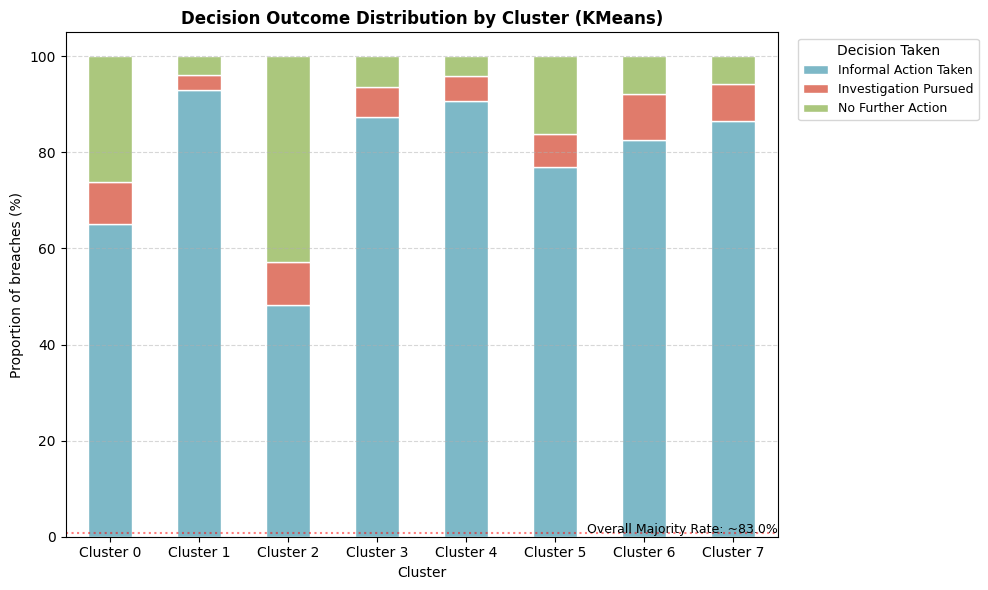

decision_taken,Informal Action Taken,Investigation Pursued,No Further Action
cluster,,,
0,0.651769,0.085661,0.262570
1,0.929682,0.031102,0.039216
2,0.481682,0.089552,0.428765
3,0.872918,0.063979,0.063103
4,0.907984,0.050633,0.041383
5,0.769547,0.067901,0.162551
6,0.825849,0.096386,0.077766
7,0.865914,0.076923,0.057163


In [ ]:
# Cluster vs decision_taken, descriptive cross-tab
print("Cluster vs decision_taken — counts:")
counts = pd.crosstab(df_analysis["cluster"], df_analysis[TARGET_COL], margins=True)
print(counts.to_string())

print("\nRow proportions (within each cluster):")
row_proportions = pd.crosstab(df_analysis["cluster"], df_analysis[TARGET_COL], normalize="index").round(4)
print(row_proportions.to_string())

# Stacked bar visualisation using the shared helper
plot_cluster_distribution(
    cluster_labels=kmeans_labels,
    decision_labels=df_analysis[TARGET_COL],
    class_labels=CLASS_LABELS,
    title="Decision Outcome Distribution by Cluster (KMeans)",
)

In [36]:
def assign_breach_to_cluster_kmeans(breach_dict):
    new_breach_df = pd.DataFrame([breach_dict])
    encoded = build_mlb_ohe_matrix(new_breach_df, mlb_encoder, ohe_encoder)
    # Reindex to training column order (handles any new MLB tokens in user input)
    encoded = encoded.reindex(columns=X_cluster.columns, fill_value=0)

    cluster_id = int(kmeans_final.predict(encoded.values)[0])

    cluster_members = df_analysis[df_analysis["cluster"] == cluster_id]
    outcome_dist = cluster_members[TARGET_COL].value_counts(normalize=True)

    return {
        "cluster_id": cluster_id,
        "similar_breaches_count": len(cluster_members),
        "outcome_distribution": {
            label: round(outcome_dist.get(label, 0.0) * 100, 1)
            for label in CLASS_LABELS
        },
    }

# Worked example using modal feature values
example_breach = {col: df_raw[col].mode().iloc[0] for col in MULTILABEL_COLS + CATEGORICAL_COLS}

print("Example breach input (using modal feature values):")
for key, value in example_breach.items():
    print(f"\t{key}: {value}")

result = assign_breach_to_cluster_kmeans(example_breach)
print(f"\nAssigned cluster: {result['cluster_id']}")
print(f"Similar historical breaches: {result['similar_breaches_count']}")
print(f"Outcome distribution among similar breaches:")
for outcome, pct in result["outcome_distribution"].items():
    print(f"\t{outcome}: {pct}%")

Example breach input (using modal feature values):
	data_subject_type: Patients
	data_type: Basic personal identifiers, Health data
	incident_category: Non Cyber
	incident_type: Other non-cyber incident
	no_data_subjects_affected: 1 to 9
	time_taken_to_report: 24 hours to 72 hours

Assigned cluster: 4
Similar historical breaches: 2054
Outcome distribution among similar breaches:
	Informal Action Taken: 90.8%
	Investigation Pursued: 5.1%
	No Further Action: 4.1%


c:\Users\elsad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [37]:
assert len(kmeans_labels) == len(X_cluster), "Label / row count mismatch"
print(f"1. Every row assigned a cluster label ({len(kmeans_labels)} labels)")

assert len(np.unique(kmeans_labels)) == final_k, f"Expected {final_k} clusters, found {len(np.unique(kmeans_labels))}"
print(f"2. Requested K={final_k} matches actual unique clusters")

unique, counts = np.unique(kmeans_labels, return_counts=True)
assert (counts > 0).all(), "Empty clusters found"
print(f"3. No empty clusters (sizes: {dict(zip(unique.tolist(), counts.tolist()))})")

assert ari >= -0.05, f"ARI unexpectedly negative ({ari:.4f})"
print(f"4. ARI ({ari:.4f}) is at or above random baseline")

new_point = X_cluster.iloc[[0]].values
predicted = kmeans_final.predict(new_point)
assert predicted[0] == kmeans_labels[0], f"predict() on training row 0 gave {predicted[0]}, expected {kmeans_labels[0]}"
print(f"5. predict() on a known training row returns its assigned cluster")

1. Every row assigned a cluster label (9250 labels)
2. Requested K=8 matches actual unique clusters
3. No empty clusters (sizes: {0: 537, 1: 1479, 2: 737, 3: 1141, 4: 2054, 5: 972, 6: 913, 7: 1417})
4. ARI (0.0289) is at or above random baseline
5. predict() on a known training row returns its assigned cluster


c:\Users\elsad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [38]:
kmeans_summary = {
    "model": "KMeans MLB+OHE",
    "K": final_k,
    "ARI": round(ari, 4),
    "NMI": round(nmi, 4),
    "silhouette_euclidean": round(silhouette_score(X_cluster, kmeans_labels, metric="euclidean"), 4),
    "inertia": round(float(kmeans_final.inertia_), 2),
}
print("KMeans summary (for comparison with KModes notebook):")
for key, value in kmeans_summary.items():
    print(f"\t{key}: {value}")

KMeans summary (for comparison with KModes notebook):
	model: KMeans MLB+OHE
	K: 8
	ARI: 0.0289
	NMI: 0.0433
	silhouette_euclidean: 0.1503
	inertia: 25246.97


In [39]:
artifacts_path = Path(ARTIFACTS_PATH)
artifacts_path.mkdir(parents=True, exist_ok=True)

with open(artifacts_path / "kmeans_final.pkl", "wb") as f:
    pickle.dump(kmeans_final, f)

save_encoders(mlb_encoder, ohe_encoder, ARTIFACTS_PATH)

cluster_characteristics = {}
for cluster_id in range(final_k):
    cluster_rows = df_analysis[df_analysis["cluster"] == cluster_id]
    outcome_dist = cluster_rows[TARGET_COL].value_counts(normalize=True)
    cluster_characteristics[str(cluster_id)] = {
        "size": int(len(cluster_rows)),
        "outcome_distribution": {
            label: round(float(outcome_dist.get(label, 0.0)) * 100, 1)
            for label in CLASS_LABELS
        },
        "feature_columns_order": list(X_cluster.columns),
    }
with open(artifacts_path / "kmeans_cluster_characteristics.json", "w") as f:
    json.dump(cluster_characteristics, f, indent=2)

print(f"Saved KMeans artifacts to {artifacts_path}/")
for path in sorted(artifacts_path.iterdir()):
    print(f"\t{path.name}")

Saved KMeans artifacts to ..\artifacts/
	allowed_values.json
	catboost_final.cbm
	feature_metadata.json
	kmeans_cluster_characteristics.json
	kmeans_final.pkl
	mlb_data_subject_type.pkl
	mlb_data_type.pkl
	ohe.pkl
